In [126]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA, KernelPCA

In [127]:
def show_grid(original, reconstructed, n=5):
    original = np.array(original)
    reconstructed = np.array(reconstructed)
    plt.figure(figsize=(6, 5))
    
    # Top row: originals
    for i in range(n):
        plt.subplot(2, n, i + 1)
        plt.imshow(original[i].reshape(16, 16), cmap='gray')
        plt.axis('off')
        if i == 2:
            plt.title("Original Images")

    # Bottom row: reconstructions
    for i in range(n):
        plt.subplot(2, n, i + 1 + n)
        plt.imshow(reconstructed[i].reshape(16, 16), cmap='gray')
        plt.axis('off')
        if i == 2:
            plt.title("Reconstructed Images")

    plt.tight_layout()
    plt.show()

In [128]:
digits = pd.read_csv("digit9.csv", header=None)
rng = np.random.RandomState(0)

noise = rng.normal(scale=0.25, size=digits.shape)
digits_noisy = digits + noise

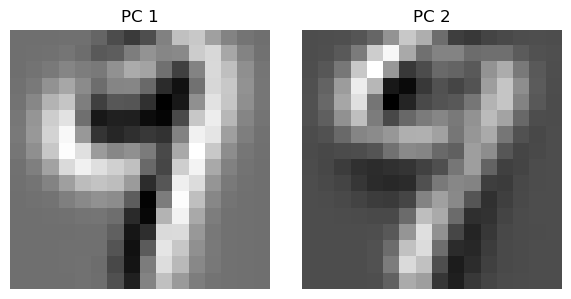

In [129]:
#Problem 1

pca = PCA()
pca.fit(digits)
fig, axes = plt.subplots(1, 2, figsize=(6, 3))

axes[0].imshow(pca.components_[0].reshape(16, 16), cmap='gray')
axes[0].set_title('PC 1')
axes[0].axis('off')

axes[1].imshow(pca.components_[1].reshape(16, 16), cmap='gray')
axes[1].set_title('PC 2')
axes[1].axis('off')

plt.tight_layout()
plt.show()

PC 1 captures the most dominant source of variation across the digit 9 images. It shows a clear contrast between the left and right sides of the image, with bright regions on the left and dark regions forming a vertical stroke pattern in the center and right. This suggests that PC 1 is capturing variation in the overall horizontal stroke structure and the position of the main vertical tail of the digit 9.
PC 2 captures the second most important source of variation. It shows a strong contrast in the upper portion of the image, with bright and dark regions concentrated around the top center, which corresponds to the loop at the top of the digit 9. This suggests that PC 2 is capturing variation in how open or closed the circular loop is, as well as differences in where the loop is positioned vertically within the image.
Together, the two components capture the broadest structural differences between handwritten versions of the digit 9, namely how the tail is drawn and how the loop is formed, which are the two main ways that this digit varies from person to person.

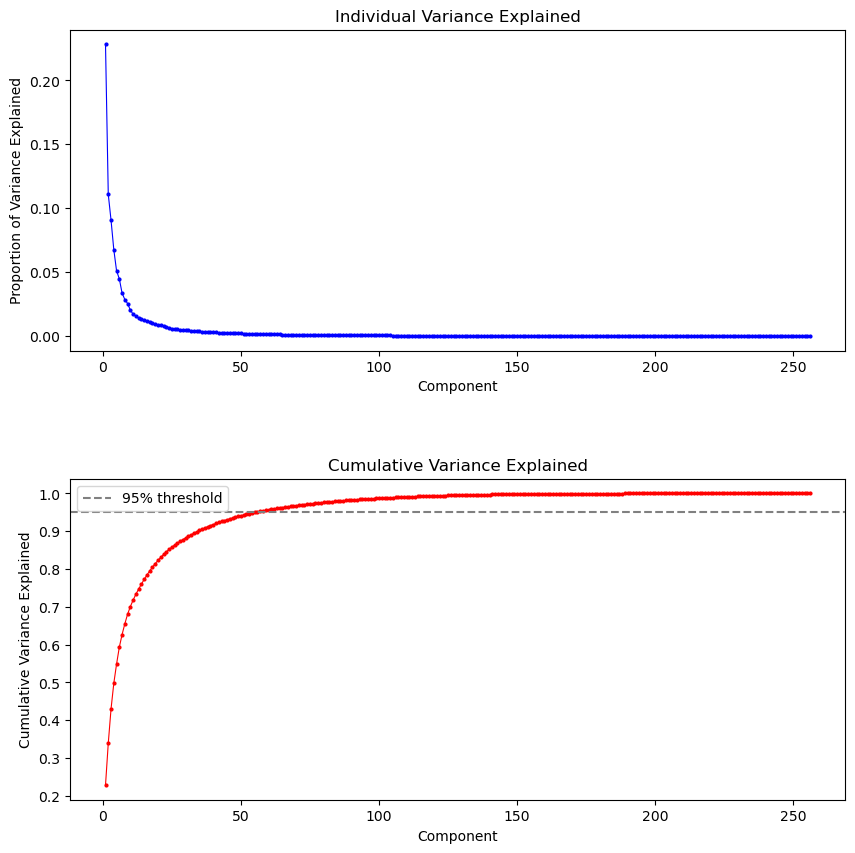

Number of components needed to explain 95% of variance: 56


In [130]:
#Problem 2

explained = pca.explained_variance_ratio_
cumulative = np.cumsum(explained)

fig, axes = plt.subplots(2, 1, figsize=(10, 10))

axes[0].plot(range(1, len(explained) + 1), explained, 'bo-', markersize=2, linewidth=0.8)
axes[0].set_xlabel('Component')
axes[0].set_ylabel('Proportion of Variance Explained')
axes[0].set_title('Individual Variance Explained')

axes[1].plot(range(1, len(cumulative) + 1), cumulative, 'ro-', markersize=2, linewidth=0.8)
axes[1].axhline(y=0.95, color='gray', linestyle='--', label='95% threshold')
axes[1].set_xlabel('Component')
axes[1].set_ylabel('Cumulative Variance Explained')
axes[1].set_title('Cumulative Variance Explained')
axes[1].legend()

plt.subplots_adjust(hspace=0.4)
plt.show()

n_95 = np.argmax(cumulative >= 0.95) + 1
print(f"Number of components needed to explain 95% of variance: {n_95}")

The first component alone explains about 22% of the variance, and the curve drops off steeply after the first few components. Looking at the cumulative plot, the 95% threshold is crossed at around 50 to 60 components. This is notable because the images have 256 dimensions in total, yet only a small fraction of that is needed to capture nearly all the meaningful variation. This suggests that the intrinsic dimensionality of the digit 9 data is quite low, meaning that handwritten 9s mostly vary along a small number of consistent structural directions rather than varying freely across all 256 pixels.

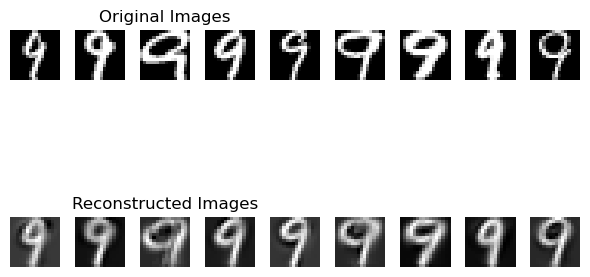

In [131]:
#Problem 3

pca10 = PCA(n_components=10)
X_projected = pca10.fit_transform(digits)
X_reconstructed = pca10.inverse_transform(X_projected)

show_grid(digits.values[:9], X_reconstructed[:9], n=9)

The reconstructed images clearly retain the overall shape and structure of the digit 9. The general form of the loop at the top, the downward tail, and the overall stroke layout are all recognizable and well preserved across all 9 examples. This confirms that 10 components are sufficient to capture the dominant structural patterns that define the digit.
The reconstructions are noticeably smoother and softer than the originals. Sharp edges and crisp stroke boundaries visible in the originals become blurred in the reconstructions. Fine pixel-level details such as the precise thickness of strokes and the sharpness of corners are also lost. Some of the more unusual or stylistic variations in the originals, such as the more angular or tilted versions of the digit seen in the top row, are regularized toward a more average-looking 9 in the reconstruction. This happens because those idiosyncratic features are captured by later principal components that were discarded when we kept only 10.
Overall this illustrates the tradeoff in PCA compression: the global, shared structure is preserved well, but individual-specific fine details are smoothed away.

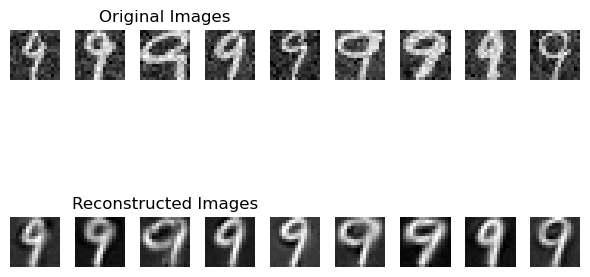

In [132]:
#Problem 4

pca10_noisy = PCA(n_components=10)
X_noisy_projected = pca10_noisy.fit_transform(digits_noisy)
X_noisy_reconstructed = pca10_noisy.inverse_transform(X_noisy_projected)

show_grid(digits_noisy.values[:9], X_noisy_reconstructed[:9], n=9)

PCA finds the directions of maximum variance in the data. The true digit structure is consistent across samples and therefore contributes strongly to the top components. Random noise, by contrast, is inconsistent and spreads its variance across many dimensions rather than concentrating it in a few. By keeping only 10 components, PCA effectively discards the dimensions that are dominated by noise and retains only the signal, producing cleaner reconstructions.

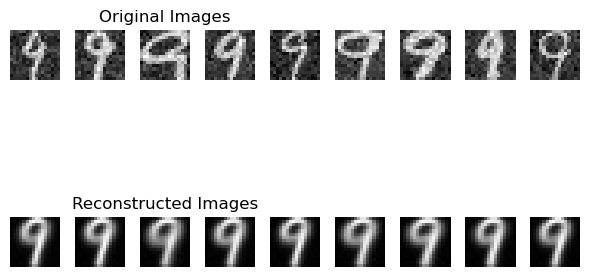

In [133]:
#Problem 5

kpca = KernelPCA(n_components=70, kernel='rbf', fit_inverse_transform=True)
X_kpca_projected = kpca.fit_transform(digits_noisy)
X_kpca_reconstructed = kpca.inverse_transform(X_kpca_projected)

show_grid(digits_noisy.values[:9], X_kpca_reconstructed[:9], n=9)

Standard PCA can only capture linear structure in the data, meaning it finds straight directions of maximum variance in the original pixel space. KernelPCA with the rbf kernel implicitly maps the data into a higher dimensional feature space where non-linear relationships between pixels become linear, allowing it to capture more complex and curved patterns in the digit images. Noise tends to be distributed in a scattered, non-linear way across pixel space, so the kernel approach can separate it from the true signal more effectively than linear PCA. This means the components retained by KernelPCA carry more genuine digit structure and less noise, potentially producing cleaner and smoother reconstructions.

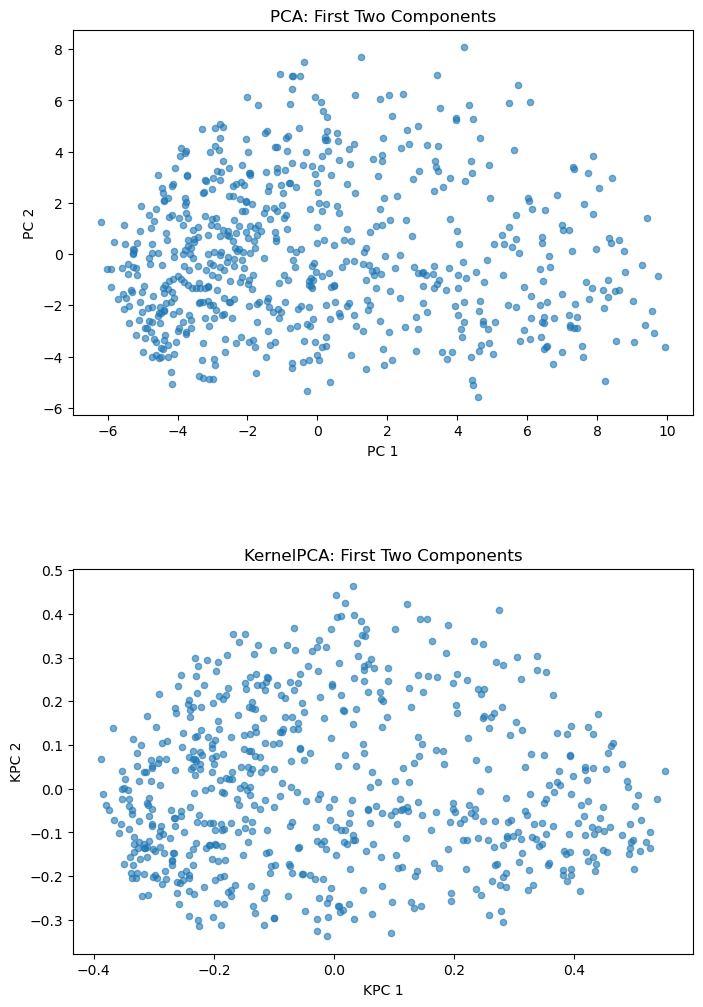

In [134]:
#Problem 6 

pca2 = PCA(n_components=2)
X_pca2 = pca2.fit_transform(digits_noisy)

kpca2 = KernelPCA(n_components=2, kernel='rbf')
X_kpca2 = kpca2.fit_transform(digits_noisy)

fig, axes = plt.subplots(2, 1, figsize=(8, 12))

axes[0].scatter(X_pca2[:, 0], X_pca2[:, 1], s=20, alpha=0.6)
axes[0].set_title('PCA: First Two Components')
axes[0].set_xlabel('PC 1')
axes[0].set_ylabel('PC 2')

axes[1].scatter(X_kpca2[:, 0], X_kpca2[:, 1], s=20, alpha=0.6)
axes[1].set_title('KernelPCA: First Two Components')
axes[1].set_xlabel('KPC 1')
axes[1].set_ylabel('KPC 2')

plt.subplots_adjust(hspace=0.4)
plt.show()

Both plots show a single diffuse cloud of points with no clear cluster boundaries, which is expected since the dataset contains only one digit class.
The PCA plot shows a wider and more asymmetric spread, stretching from about -6 to 10 on the horizontal axis, with points thinning out toward the right. KernelPCA produces a much more compact and symmetric cloud, with all points falling within roughly -0.4 to 0.5 on both axes. This compression is expected behavior of the rbf kernel with default gamma, which measures similarity non-linearly and naturally bounds the output values.
Overall both representations show a similar organizational structure, but PCA produces a more stretched and spread out embedding while KernelPCA produces a more compact and evenly distributed one.